<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/03_health_step_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw_health_data = """Date,Steps,SleepHours,RestingHeartRate,ActiveCalories
2026-02-01,10450,7.5,62,450
2026-02-02,8900,6.8,65,380
2026-02-03,0,5.2,74,120
2026-02-04,11200,8.0,60,510
2026-02-05,12400,7.8,59,540
2026-02-06,7800,6.5,67,330
2026-02-07,13500,8.2,58,600
2026-02-08,6200,6.0,70,290
2026-02-09,9100,7.1,64,410
2026-02-10,0,5.5,72,150
2026-02-11,10800,7.4,61,480
2026-02-12,11500,7.9,60,505
2026-02-13,8400,6.4,68,360
2026-02-14,14200,8.5,57,630
"""

with open("daily_health.csv", "w") as f:
    f.write(raw_health_data.strip())

print("daily_health.csv created successfully.")

daily_health.csv created successfully.


In [2]:
# Load dataset
df_health = pd.read_csv("daily_health.csv")
df_health["Date"] = pd.to_datetime(df_health["Date"])

# 1. Replace zero step days with NaN, then impute with median
df_health["Steps"] = df_health["Steps"].replace(0, np.nan)
step_median = df_health["Steps"].median()
df_health["Steps"] = df_health["Steps"].fillna(step_median)

# 2. Add goal achievement flag (1 if >= 10,000 steps, else 0)
df_health["GoalReached"] = np.where(df_health["Steps"] >= 10000, 1, 0)

# 3. Calculate 3-day rolling smoothed average
df_health["Steps_3Day_Avg"] = (
    df_health["Steps"].rolling(window=3, min_periods=1).mean()
)

print("--- Cleaned Health Log Preview ---")
print(
    df_health[
        ["Date", "Steps", "Steps_3Day_Avg", "GoalReached", "SleepHours"]
    ]
)

--- Cleaned Health Log Preview ---
         Date    Steps  Steps_3Day_Avg  GoalReached  SleepHours
0  2026-02-01  10450.0    10450.000000            1         7.5
1  2026-02-02   8900.0     9675.000000            0         6.8
2  2026-02-03  10625.0     9991.666667            1         5.2
3  2026-02-04  11200.0    10241.666667            1         8.0
4  2026-02-05  12400.0    11408.333333            1         7.8
5  2026-02-06   7800.0    10466.666667            0         6.5
6  2026-02-07  13500.0    11233.333333            1         8.2
7  2026-02-08   6200.0     9166.666667            0         6.0
8  2026-02-09   9100.0     9600.000000            0         7.1
9  2026-02-10  10625.0     8641.666667            1         5.5
10 2026-02-11  10800.0    10175.000000            1         7.4
11 2026-02-12  11500.0    10975.000000            1         7.9
12 2026-02-13   8400.0    10233.333333            0         6.4
13 2026-02-14  14200.0    11366.666667            1         8.5


In [3]:
# 1. Goal milestone rate
days_tracked = len(df_health)
goals_met = df_health["GoalReached"].sum()
success_rate = (goals_met / days_tracked) * 100

print(
    f"Target Achieved: {goals_met}/{days_tracked} days ({success_rate:.1f}%)"
)

# 2. Pearson correlation: Sleep Duration vs Resting Heart Rate
corr_sleep_rhr = df_health["SleepHours"].corr(df_health["RestingHeartRate"])
print(
    f"Correlation (Sleep Hours vs Resting Heart Rate): {corr_sleep_rhr:.2f}"
)

Target Achieved: 9/14 days (64.3%)
Correlation (Sleep Hours vs Resting Heart Rate): -0.99


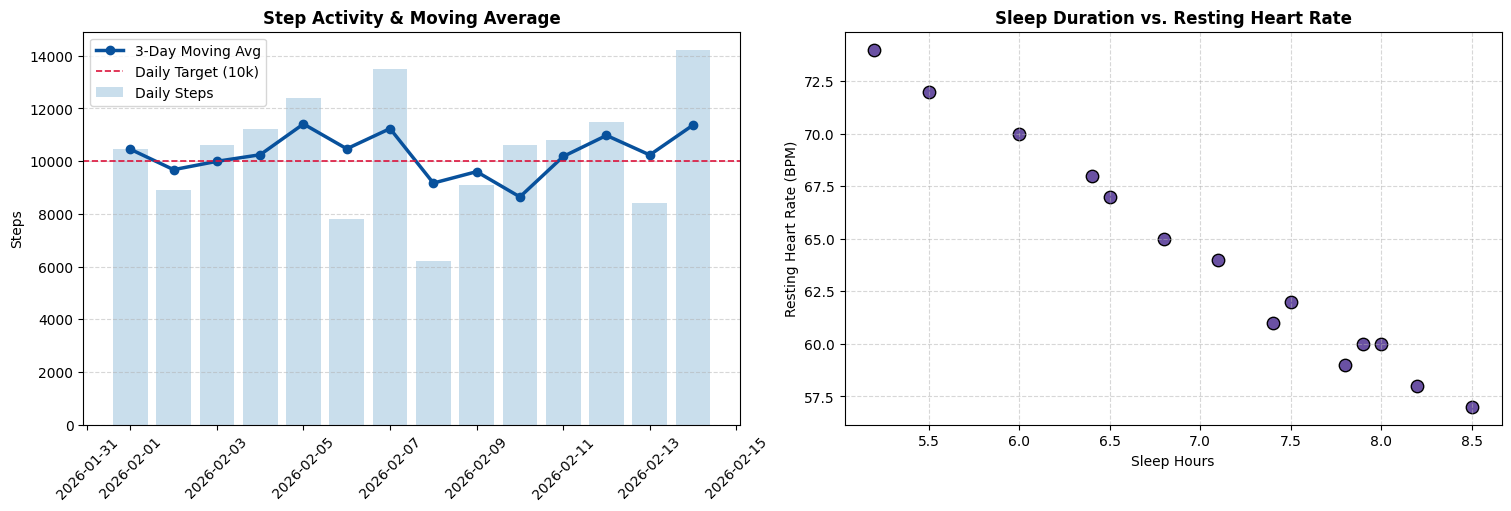

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), layout="constrained")

# --- Chart 1: Daily Steps + 3-Day Rolling Trend ---
ax1.bar(
    df_health["Date"],
    df_health["Steps"],
    color="#a6c8e0",
    alpha=0.6,
    label="Daily Steps",
)
ax1.plot(
    df_health["Date"],
    df_health["Steps_3Day_Avg"],
    color="#08519c",
    linewidth=2.5,
    marker="o",
    label="3-Day Moving Avg",
)
ax1.axhline(
    10000,
    color="crimson",
    linestyle="--",
    linewidth=1.2,
    label="Daily Target (10k)",
)
ax1.set_title("Step Activity & Moving Average", fontsize=12, weight="bold")
ax1.set_ylabel("Steps")
ax1.tick_params(axis="x", rotation=45)
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# --- Chart 2: Sleep Duration vs Resting Heart Rate ---
ax2.scatter(
    df_health["SleepHours"],
    df_health["RestingHeartRate"],
    color="#6a51a3",
    s=80,
    edgecolor="black",
)
ax2.set_title(
    "Sleep Duration vs. Resting Heart Rate", fontsize=12, weight="bold"
)
ax2.set_xlabel("Sleep Hours")
ax2.set_ylabel("Resting Heart Rate (BPM)")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.show()